#  **Tools**

In [1]:
# Tool - 1 [News Search Tool]
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

search_tool.invoke('who is ansh lamba?')

"I am a passionate Data Engineer with over 3 years of experience turning raw data into meaningful insights. I work with modern tools like Azure Data Factory, Databricks, Azure Synapse Analytics, Delta Lake, and the Data Lakehouse to build efficient data pipelines and solutions in the cloud. I’m Ansh - an AI Data Engineer who genuinely loves turning complex data problems into… · Experience: J.D. Irving, Limited · Education: Cape Breton University · Location: Toronto · 500+... Recognized as a Databricks MVP and featured on Billboard for my contributions to data engineering learning, I combine hands-on expertise with a passion for teaching. As a Data Engineering Mentor, I’ve guided 100K+ students across platforms, including YouTube, helping individuals break into the world of data engineering. Today, let me share my story with you all. How did I start my data journey? What were the resources I used to get started? Let's answer all these questions today. I come from a non-tech background,.

In [2]:
# Tool - 2 [Wikipedia search Tool]
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia_tool = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())

wikipedia_tool.invoke("Pakistan")

"Page: Pakistan\nSummary: Pakistan, officially the Islamic Republic of Pakistan, is a country in South Asia. It is the fifth-most populous country, with a population of over 241.5 million, having the second-largest Muslim population as of 2023. Islamabad is the nation's capital, while Karachi is its largest city and financial centre. Pakistan is the 33rd-largest country by area. Bounded by the Arabian Sea on the south, the Gulf of Oman on the southwest, and the Sir Creek on the southeast, it shares land borders with India to the east; Afghanistan to the west; Iran to the southwest; and China to the northeast. It shares a maritime border with Oman in the Gulf of Oman, and is separated from Tajikistan in the northwest by Afghanistan's narrow Wakhan Corridor.\nPakistan is the site of several ancient cultures, including the 8,500-year-old Neolithic site of Mehrgarh in Balochistan, the Indus Valley Civilisation of the Bronze Age, and the ancient Gandhara civilisation. The regions that compo

In [3]:
# Tool - 3 [Custom Tool]

from langchain.tools import tool

@tool
def enterprise_tool(query: str) -> str:
    """This tool is used to send emails to the enterprise"""
    return 'Email send'

In [4]:
# toolkit
ToolKit = [search_tool, wikipedia_tool]

In [5]:
ToolKit

[DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='wt-wt', safesearch='moderate', time='y', max_results=5, backend='auto', source='text')),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from '/home/dark/miniconda3/envs/genai_env/lib/python3.12/site-packages/wikipedia/__init__.py'>, top_k_results=3, lang='en', load_all_available_meta=False, doc_content_chars_max=4000))]

# **ReAct Agent**

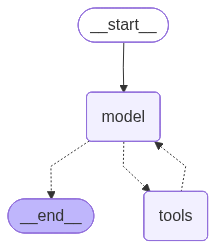

In [6]:
from langchain.agents import create_agent
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

model = ChatGroq(
    model='openai/gpt-oss-20b',
    temperature=0.1,
    max_tokens=1000,
    timeout=40
)

agent = create_agent(model, tools=ToolKit)
agent

# **ReAct Agent Invoke with streams**

In [8]:
query = 'who was nekola tesla and how he died?'

events = agent.stream(
    {"messages": [("user", query)]},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

who was nekola tesla and how he died?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (fc_45900e63-5c88-4671-b72b-35dcaa92095c)
 Call ID: fc_45900e63-5c88-4671-b72b-35dcaa92095c
  Args:
    query: Nikola Tesla death cause
================================= Tool Message =================================
Name: wikipedia

Page: List of Sanctuary characters
Summary: The characters in the Canadian science fiction-fantasy television series Sanctuary are predominantly "abnormals": advanced humans or creatures, and the show centers on bringing other abnormals to the Sanctuary in the fictional Old City, for the purpose of protecting the public, as well as the abnormals themselves. Most of the Sanctuary team are abnormals, despite looking human: Helen Magnus (Amanda Tapping) has longevity, John Druitt (Christopher Heyerdahl) and Ashley Magnus (Emilie Ullerup) 

# **Manually Binding The LLM With Tools**

In [9]:
model.invoke("what's the latest news about pakistan?")

AIMessage(content='I don’t have real‑time access to the internet, so I can’t pull in the very latest headlines that are breaking right now.  However, I can give you a quick snapshot of the most significant developments in Pakistan that have been making headlines in the past few months (through late\u202f2024 and early\u202f2025).  For the freshest updates, you’ll want to check a reputable news outlet or a real‑time news aggregator.\n\n---\n\n## 1. Political Landscape\n\n| Issue | Key Points | Current Status |\n|-------|------------|----------------|\n| **2025 General Elections** | • The elections were held in early 2025 after a delayed schedule due to security concerns.<br>• The Pakistan Muslim League‑N (PML‑N) and Pakistan Tehreek‑e‑Insaf (PTI) were the main contenders.<br>• The election was largely peaceful, but there were isolated incidents of violence in some provinces. | • The results are still being finalized; preliminary counts show a close race between PML‑N and PTI.<br>• The E

In [12]:
# With binding
model_binded = model.bind_tools(ToolKit)
model_binded.invoke("What's the latest news about pakistan?")

AIMessage(content='', additional_kwargs={'reasoning_content': 'User asks: "What\'s the latest news about Pakistan?" We need to provide latest news. We should use duckduckgo_search to get current news. Let\'s search.', 'tool_calls': [{'id': 'fc_0d3a5e24-bf13-4f4d-a034-4e1dbed7a6d8', 'function': {'arguments': '{"query":"latest news Pakistan"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 213, 'total_tokens': 275, 'completion_time': 0.064553767, 'completion_tokens_details': {'reasoning_tokens': 34}, 'prompt_time': 0.01040214, 'prompt_tokens_details': None, 'queue_time': 0.044359089, 'total_time': 0.074955907}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ca827-ab56-7192-b73a-c2eccdcb36b3-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'lates